In [ ]:
from tensorflow.keras.layers import Dense,Input
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt

2026-01-17 23:45:32.857148: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-17 23:45:32.858036: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-17 23:45:32.984580: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-17 23:45:36.023172: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [ ]:
df=pd.read_csv("Multiclass Diabetes Dataset.csv")
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0
2,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0
3,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
4,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0


In [ ]:
df[["Class"]].value_counts()

Class
2        128
0         96
1         40
Name: count, dtype: int64

In [ ]:
ss=StandardScaler() 
for col_name in ['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL','VLDL', 'BMI']:
    encoder=ss.fit_transform(df[[col_name]])
    df.drop(columns=col_name)
    df[col_name]=encoder
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
0,-1.095445,0.047217,-0.243168,-0.401231,-0.772794,-0.306535,-0.990860,2.676598,-1.132823,-0.316475,-0.516691,0
1,0.912871,-2.327116,-0.293227,-0.239960,-0.772794,-0.695151,-0.595116,-0.182261,-0.431615,-0.284154,-0.713387,0
2,0.912871,-1.634602,0.357546,-0.401231,-0.772794,0.237527,-0.911711,-0.841997,-0.531788,-0.348796,-1.106778,0
3,-1.095445,-0.447436,-0.843881,-0.622980,-1.127156,-1.316936,-0.911711,-0.402173,-1.032651,-0.348796,-1.106778,0
4,-1.095445,0.047217,-0.918970,-0.360914,-1.127156,-0.772874,-0.674265,-0.622085,-0.431615,-0.284154,-0.516691,0


In [ ]:
model=Sequential([ #  neuron network architcteur 
    Input(shape=(11,)),
    Dense(16, activation="selu",kernel_initializer="lecun_normal"),
    Dense(8, activation="selu",kernel_initializer="lecun_normal"),
    Dense(4, activation="selu",kernel_initializer="lecun_normal"),
    Dense(3, activation="softmax",kernel_initializer="glorot_uniform")

])

In [ ]:
model.compile( 
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [ ]:
x=df[['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL','VLDL', 'BMI']]
y=df["Class"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
history = model.fit( 
    x_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.3975 - loss: 1.1436 - val_accuracy: 0.2558 - val_loss: 1.2943
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4075 - loss: 1.0721 - val_accuracy: 0.3256 - val_loss: 1.1725
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4874 - loss: 1.0032 - val_accuracy: 0.4419 - val_loss: 1.0685
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6934 - loss: 0.8965 - val_accuracy: 0.5581 - val_loss: 0.9885
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6980 - loss: 0.8690 - val_accuracy: 0.6977 - val_loss: 0.9090
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7494 - loss: 0.7992 - val_accuracy: 0.7209 - val_loss: 0.8368
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7608 - loss: 0.7659 - val_accuracy: 0.7442 - val_loss: 0.7788
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8341 - loss: 0.6534 - val_accuracy: 0.74

In [ ]:
y_pred_proba=model.predict(x_test)s
y_pred_proba

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([[9.87640142e-01, 5.98868355e-03, 6.37111906e-03],
       [1.51735458e-06, 4.63755988e-03, 9.95360851e-01],
       [9.79851067e-01, 8.28776974e-03, 1.18611911e-02],
       [6.68144858e-05, 7.55955139e-03, 9.92373645e-01],
       [8.60989839e-02, 7.93090820e-01, 1.20810091e-01],
       [8.58013868e-01, 1.11794554e-01, 3.01916096e-02],
       [3.16741839e-02, 9.60989773e-01, 7.33600929e-03],
       [8.07873803e-08, 4.28381085e-04, 9.99571502e-01],
       [9.88653481e-01, 4.12341999e-03, 7.22306548e-03],
       [4.50717415e-11, 2.26652688e-07, 9.99999702e-01],
       [1.09792512e-03, 8.61945629e-01, 1.36956438e-01],
       [1.95219065e-04, 3.52121592e-01, 6.47683203e-01],
       [1.71700862e-07, 1.16421354e-04, 9.99883354e-01],
       [9.84825015e-01, 8.24049208e-03, 6.93456968e-03],
       [1.45191151e-10, 3.49452857e-05, 9.99965012e-01],
       [3.29383202e-02, 8.59072745e-01, 1.07988834e-01],
       [1.11511529e-10, 1.34538168e-05, 9.99986470e-01],
       [1.35011557e-09, 1.19131

In [ ]:
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9037 - loss: 0.2304


[0.24540655314922333, 0.8867924809455872]

In [ ]:
y_pred_class=np.argmax(y_pred_proba,axis=1)
y_pred_class

array([0, 2, 0, 2, 1, 0, 1, 2, 0, 2, 1, 2, 2, 0, 2, 1, 2, 2, 0, 2, 0, 0,
       0, 0, 2, 1, 0, 2, 2, 1, 2, 1, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0,
       2, 1, 2, 2, 1, 2, 2, 0, 0])

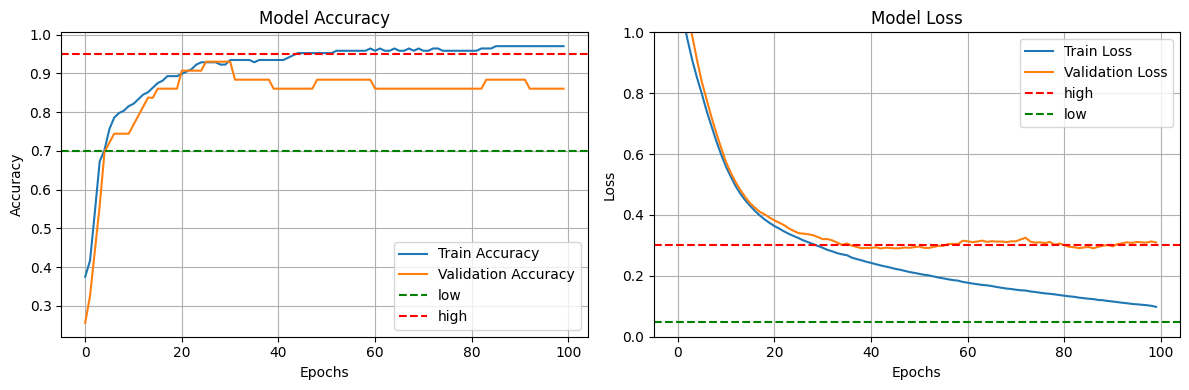

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.axhline(1-0.3,linestyle="--",c="g",label="low")
plt.axhline(1-0.05,linestyle="--",c="r",label="high")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.title("Model Loss")
plt.axhline(0.3,linestyle="--",c="r",label="high")
plt.axhline(0.05,linestyle="--",c="g",label="low")
plt.ylim((0,1))
plt.grid()
plt.legend()
plt.ylabel("Loss")

plt.tight_layout()
plt.show()